# Identifying Viraltiy Metrics - EDA

**Since the data (number of reposts) is discrete, I will use histogram plots to assess the distribution of reposts for each posts, rather than e.g. Kernel Density Estimation.**

**Note also that "data/processed/reposts.parquet" does not contain the post id, as this dataset just describes a graph connecting users. So we need to analyse the feed_posts and user_posts directly to find the distribution of the number of reposts.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

BASE_PATH = Path.cwd().parent
sys.path.append(str(BASE_PATH))

In [8]:
disability_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_#Disability.parquet")
ukranianView_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_#UkrainianView.parquet")
academicSky_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_AcademicSky.parquet")
blackSky_posts=  pd.read_parquet(BASE_PATH/"data/processed/feed_Blacksky.parquet") 
bookSky_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_BookSky.parquet")
gameDev_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_Game Dev.parquet")
greenSky_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_GreenSky.parquet")
news_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_News.parquet")
political_Science_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_Political Science.parquet")
science_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_Science.parquet")
whats_History_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_What's History.parquet")

feed_posts = [disability_posts, ukranianView_posts, academicSky_posts,
            blackSky_posts, bookSky_posts, gameDev_posts,
            greenSky_posts, news_posts, political_Science_posts,
            science_posts, whats_History_posts]

labels = ["#Disability", "#UkrainianView", "AcademicSky",
        "Blacksky", "BookSky", "Game Dev",
        "GreenSky", "News", "Political Science", "Science",
        "What's History"]

combined_feeds = pd.concat(feed_posts, ignore_index=True)
print(combined_feeds.head())

     post_id  user_id     instance          date  \
0    2238814   125049  bsky.social  202307270630   
1  165204275   272212  bsky.social  202403182351   
2   89700377   356883  bsky.social  202403182350   
3   57985819   119633  bsky.social  202403182344   
4   39046686   164073  bsky.social  202403182331   

                                                text  langs  like_count  \
0  📍 ♿️ #Disability feed pinned post 📍\n\nAny pos...  [eng]         628   
1  I got curious about this guy, and here is wher...  [eng]           1   
2     というわけで、改良すべきはdisabilityを生じさせる社会システム全体ということになる。  [jpn]           0   
3  Hi friends. I don't know how much I'll be arou...  [eng]          12   
4  The Ministry of Disabled People is limiting th...  [eng]          14   

   reply_count  repost_count reply_to replied_author thread_root  \
0           23           145     None           None        None   
1            0             0     None           None        None   
2            0             0    

Combined feeds
repost_count
0    84260
1    26990
2    13842
3     8591
4     5847
Name: count, dtype: int64
Number of total posts = 168463
90.0th percentile = 8.0
95.0th percentile = 17.0
98.0th percentile = 41.0
99.0th percentile = 72.0
99.9th percentile = 275.53800000000047
99.99th percentile = 792.1532000000007


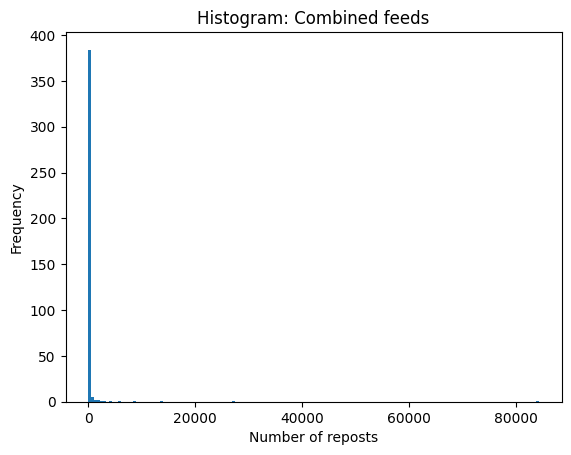

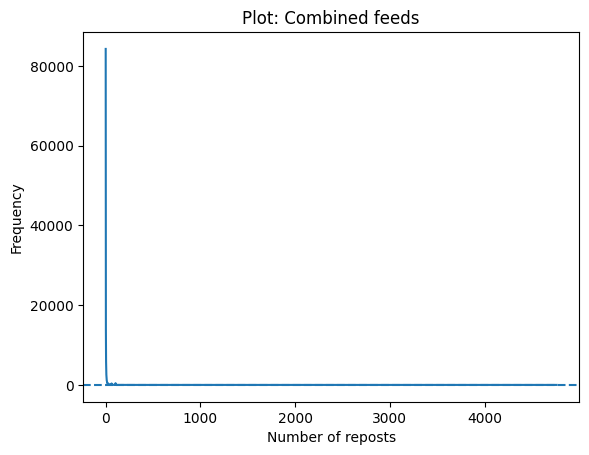

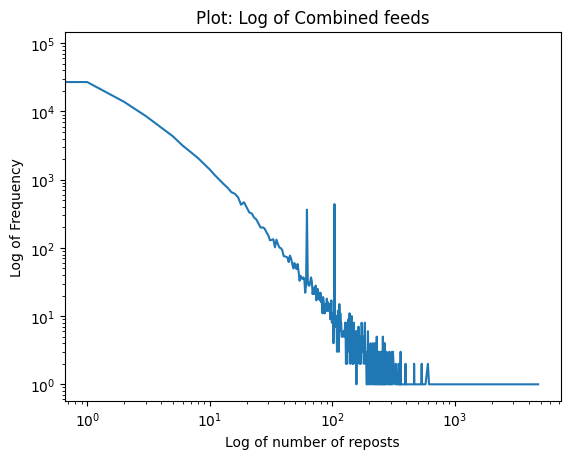

In [ ]:
# Pandas Series of frequencies (value_counts), indexed by number of reposts
repost_counts = [df["repost_count"].value_counts().sort_index() for df in feed_posts]
combined_repost_counts = combined_feeds["repost_count"].value_counts().sort_index()

print("Combined feeds")
print(f"Number of total posts = {combined_feeds.shape[0]}")
for i in [0.9,0.95,0.98,0.99,0.999,0.9999]:
    print(f"{i*100}th percentile = {combined_feeds['repost_count'].quantile(i)}") # default linear interpolation

plt.hist(combined_repost_counts, bins=150)
plt.xlabel("Number of reposts")
plt.ylabel("Frequency")
plt.title("Histogram: Combined feeds")
plt.show()

combined_repost_counts.plot()
plt.xlabel("Number of reposts")
plt.ylabel("Frequency")
plt.title("Plot: Combined feeds")
plt.axhline(0.5, linestyle='--')
plt.show()

combined_repost_counts.plot()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Log of number of reposts")
plt.ylabel("Log of Frequency")
plt.title("Plot: Log-Log of Combined feeds")
plt.show()


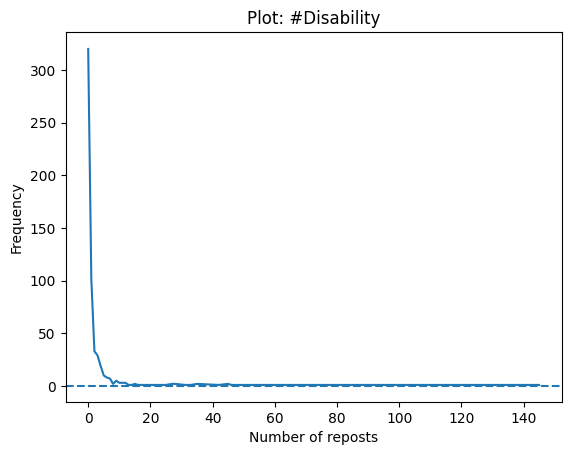

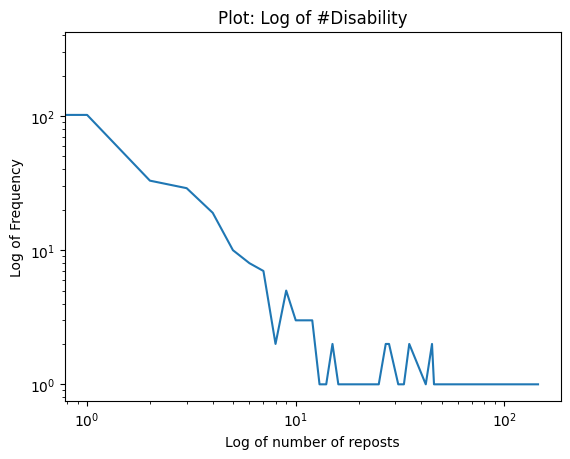

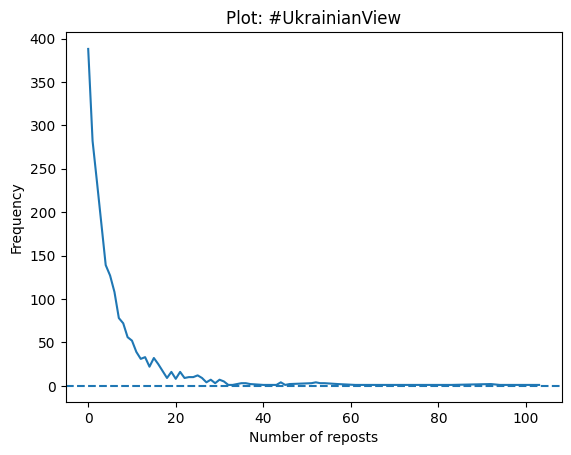

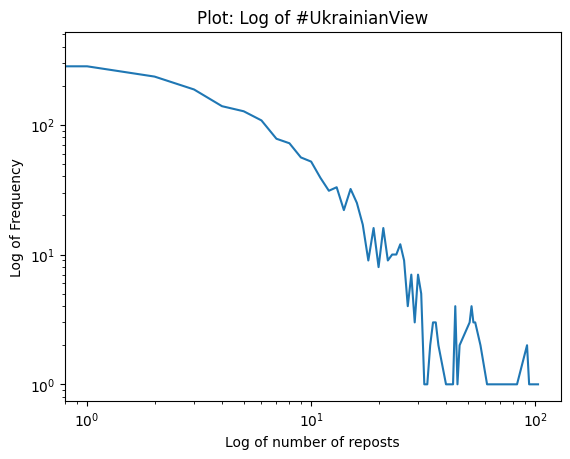

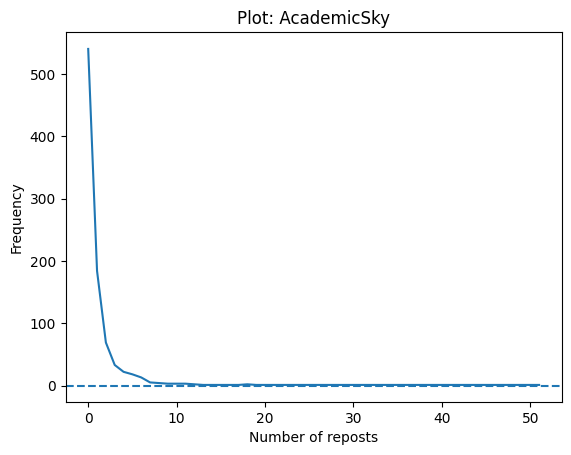

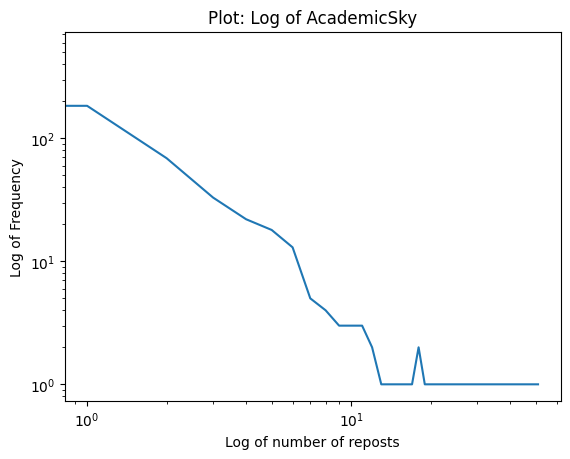

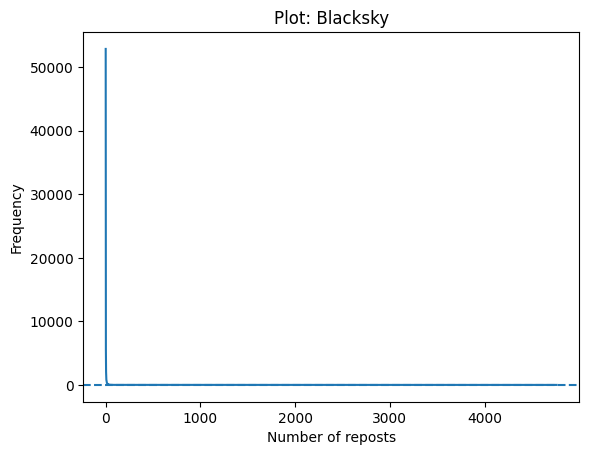

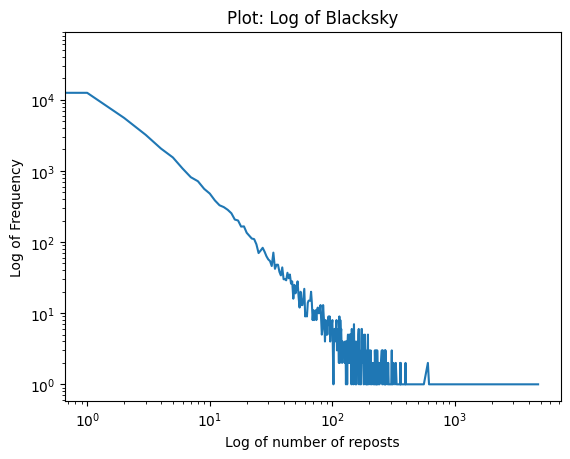

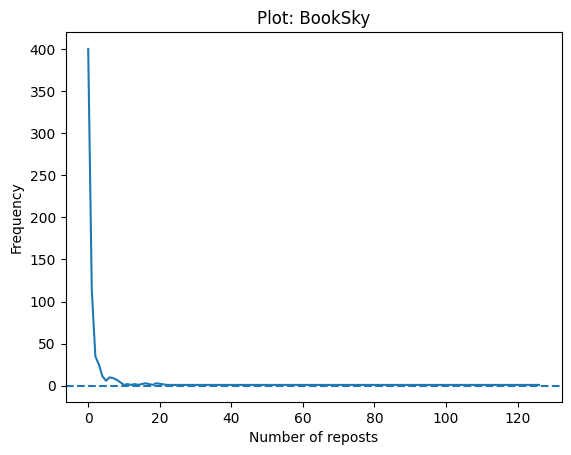

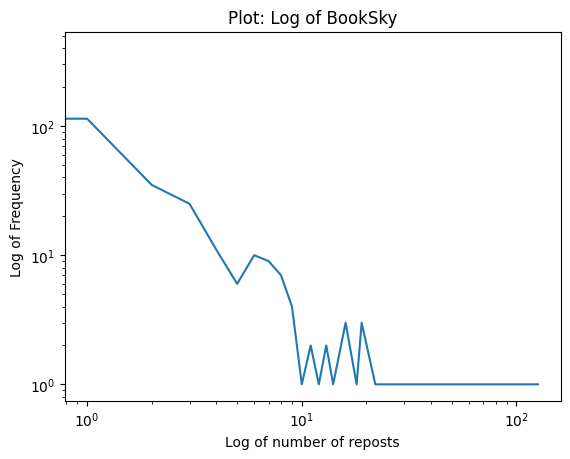

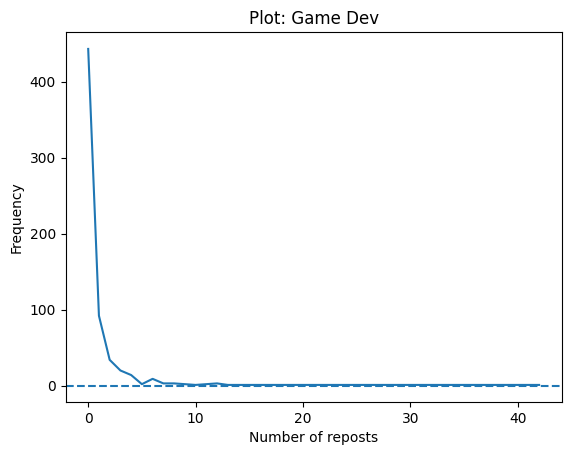

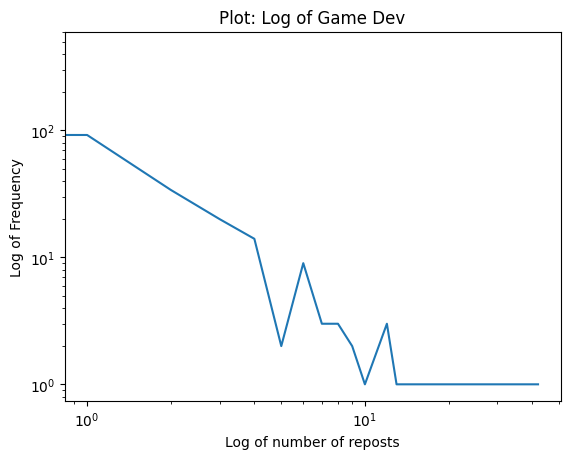

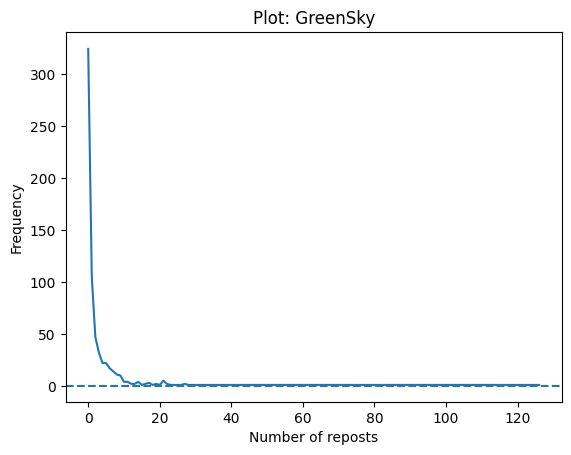

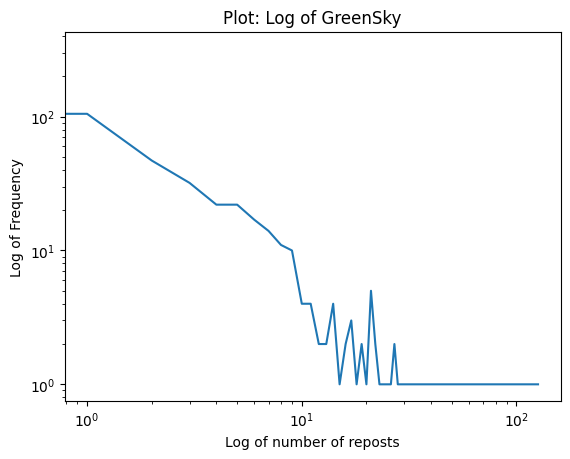

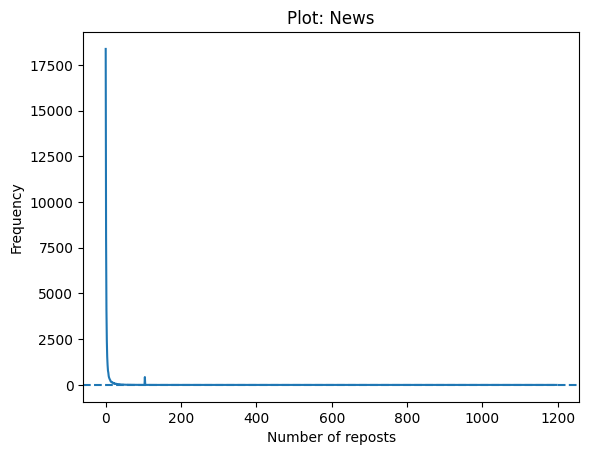

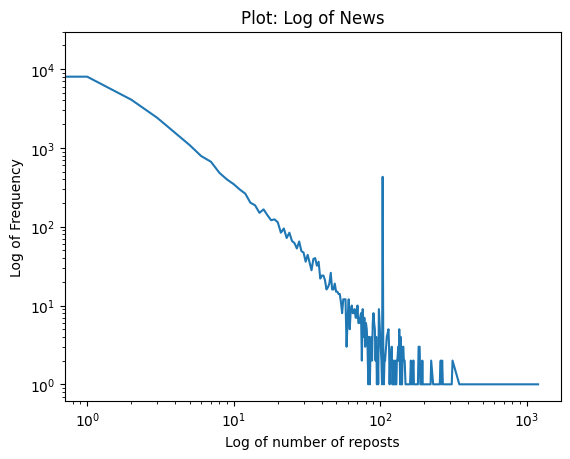

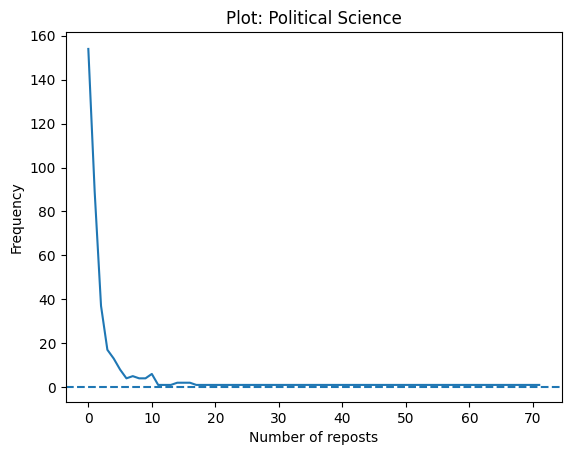

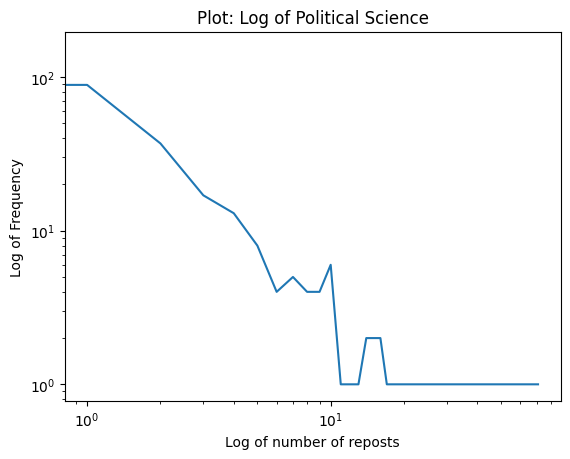

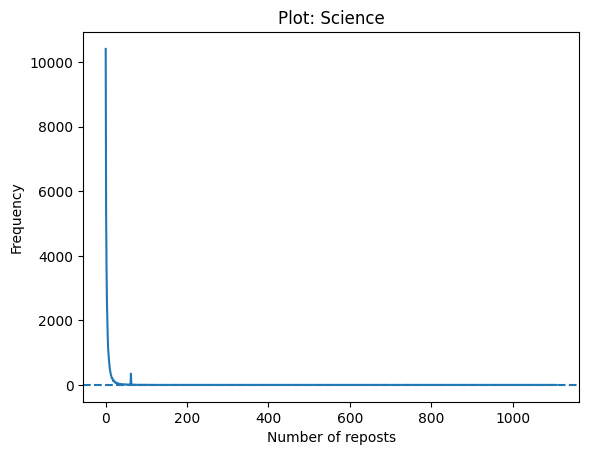

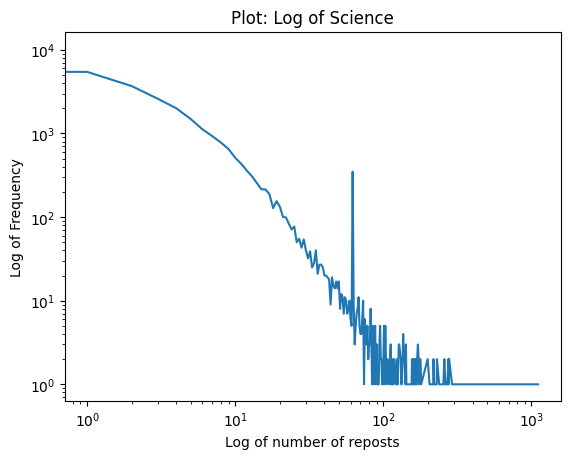

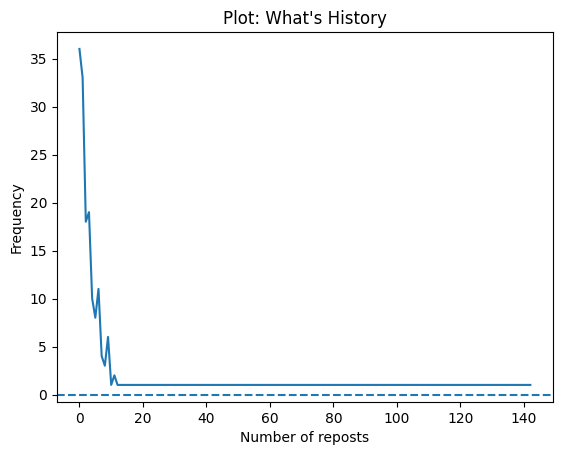

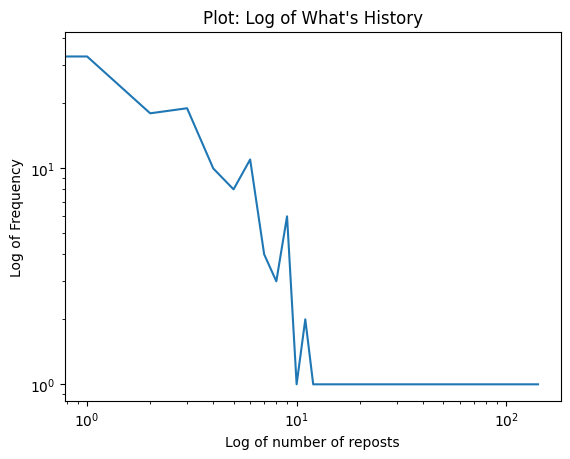

In [ ]:
for i in range(len(repost_counts)):
    repost_counts[i].plot()
    plt.xlabel("Number of reposts")
    plt.ylabel("Frequency")
    plt.title("Plot: "+labels[i])
    plt.axhline(0, linestyle='--')
    plt.show()

    repost_counts[i].plot()
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Log of number of reposts")
    plt.ylabel("Log of Frequency")
    plt.title("Plot: Log of "+labels[i])
    plt.show()